# QWEN37b Ranking Experiments

In [1]:
import os
import sys
import torch
import math
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# add repo root to PYTHONPATH
repo_root = Path.cwd().parent   # adjust if needed
sys.path.append(str(repo_root))

from aesthetic_evolution.process_batch import Qwen3VLBatchProcessor
from aesthetic_evolution.utils import build_messages, calc_ranks, plot_image_grid, ComparisonJob

/home/sjkro1/anaconda3/envs/aesthetic-evolution/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment Setup

In [2]:
model_name="Qwen/Qwen3-VL-7B-Instruct"
device="cuda" if torch.cuda.is_available() else "cpu"
image_dir = "/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images"

In [3]:
# load processor
processor = Qwen3VLBatchProcessor(model_name=model_name, device=device)

Loading model Qwen/Qwen3-VL-7B-Instruct on cuda...


Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.45it/s]


Model loaded successfully!


In [4]:
# retrieve image filepaths
image_filepaths = [img for img in os.listdir(image_dir) if img[0] == "r"]
image_filepaths.sort(key=lambda x: int(x.split("_")[-1].strip(".png"))) 

image_filepaths = np.array(image_filepaths)


In [5]:
# define inference pipeline function

def rank(prompt):

    # build jobs
    jobs = build_messages(image_filepaths, image_dir, prompt)

    # caclulate results
    results = processor.process_batch_chunked(jobs, chunk_size=32)


    # calculate ranks
    ranks = calc_ranks(results, len(image_filepaths))


    # sort indicies by rank
    sorted_idx = np.argsort(ranks)[::-1]

    grid_estimate = math.sqrt(len(image_filepaths))

    # plot image grid
    plot_image_grid(filenames=image_filepaths[sorted_idx],
                    nrows=math.ceil(grid_estimate),
                    ncols=math.floor(grid_estimate),
                    population_size=len(image_filepaths),
                    filepath=image_dir,
                    ranks=ranks[sorted_idx],
                    plot=True,
                    save_path=".",
                    image_name="Rankings")

    print("---------------------")
    for i in range(len(image_filepaths)):

        print(f"Image {image_filepaths[i]}\t Rank Score: {ranks[i]}")

    print("---------------------")





## Base Experiment

In [9]:
prompt = """You will be given two images.

IMPORTANT RULES (must be followed):
- Images that are mostly dark blobs or solid dark regions MUST be ranked lower.
- Visible line structure and repeating patterns are REQUIRED for a high score.
- Messy noise or amorphous shapes should be ranked lower.

Task:
Choose which image is more aesthetically pleasing according to the rules above.
Output ONLY '1' or '2'."""

Processing 325 jobs in chunks of 32...


100%|██████████| 11/11 [00:32<00:00,  2.98s/it]


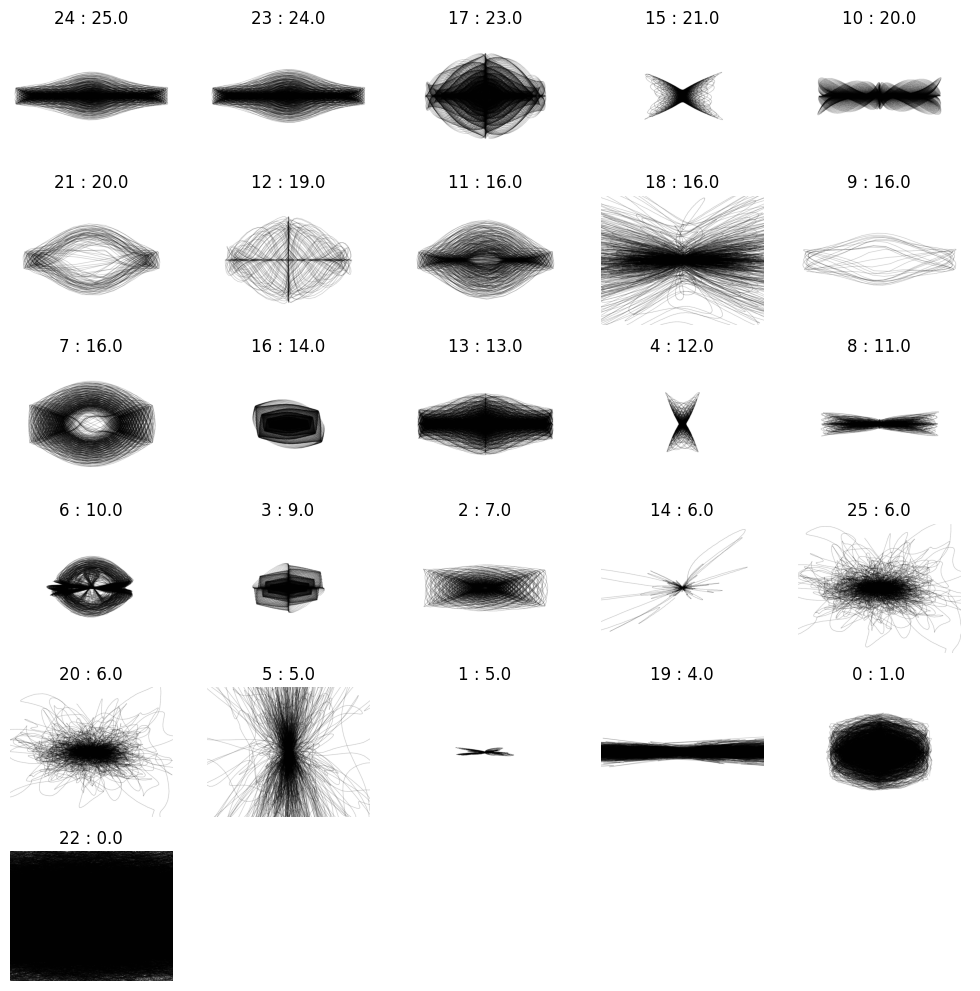

---------------------
Image run1_0.png	 Rank Score: 1.0000
Image run1_1.png	 Rank Score: 5.0000
Image run1_2.png	 Rank Score: 7.0000
Image run1_3.png	 Rank Score: 9.0000
Image run1_4.png	 Rank Score: 12.0000
Image run1_5.png	 Rank Score: 5.0000
Image run1_6.png	 Rank Score: 10.0000
Image run1_7.png	 Rank Score: 16.0000
Image run1_8.png	 Rank Score: 11.0000
Image run1_9.png	 Rank Score: 16.0000
Image run1_10.png	 Rank Score: 20.0000
Image run1_11.png	 Rank Score: 16.0000
Image run1_12.png	 Rank Score: 19.0000
Image run1_13.png	 Rank Score: 13.0000
Image run1_14.png	 Rank Score: 6.0000
Image run1_15.png	 Rank Score: 21.0000
Image run1_16.png	 Rank Score: 14.0000
Image run1_17.png	 Rank Score: 23.0000
Image run1_18.png	 Rank Score: 16.0000
Image run1_19.png	 Rank Score: 4.0000
Image run1_20.png	 Rank Score: 6.0000
Image run1_21.png	 Rank Score: 20.0000
Image run1_22.png	 Rank Score: 0.0000
Image run1_23.png	 Rank Score: 24.0000
Image run1_24.png	 Rank Score: 25.0000
Image run1_25.png	 Ran

In [18]:
rank(prompt)

## Harmonograph Prompt

In [54]:
prompt = """You will be given two images depicting harmonograph drawings, you must choose which one is more aesthetically pleasing in representing harmonic patterns.

IMPORTANT RULES (must be followed):
- Images that are mostly dark blobs or solid dark regions MUST be ranked lower.
- Visible line structure and repeating patterns are REQUIRED for a high score.
- Messy noise or amorphous shapes should be ranked lower.
- Winning designs must posses the best INTRICATE and CLEAR harmonic patterns.

Task:
Choose which image is more aesthetically pleasing according to the rules above.
Output ONLY '1' or '2'."""


Processing 325 jobs in chunks of 32...


100%|██████████| 11/11 [00:33<00:00,  3.07s/it]


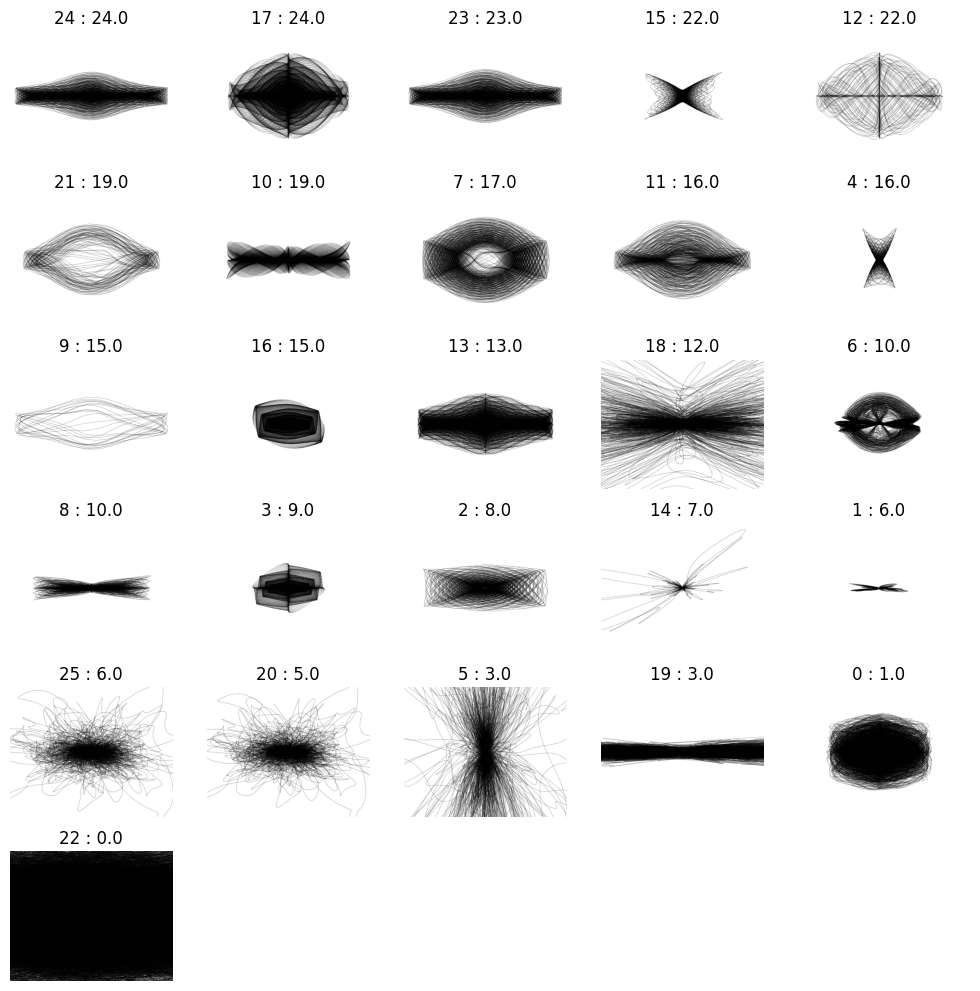

---------------------
Image run1_0.png	 Rank Score: 1.0
Image run1_1.png	 Rank Score: 6.0
Image run1_2.png	 Rank Score: 8.0
Image run1_3.png	 Rank Score: 9.0
Image run1_4.png	 Rank Score: 16.0
Image run1_5.png	 Rank Score: 3.0
Image run1_6.png	 Rank Score: 10.0
Image run1_7.png	 Rank Score: 17.0
Image run1_8.png	 Rank Score: 10.0
Image run1_9.png	 Rank Score: 15.0
Image run1_10.png	 Rank Score: 19.0
Image run1_11.png	 Rank Score: 16.0
Image run1_12.png	 Rank Score: 22.0
Image run1_13.png	 Rank Score: 13.0
Image run1_14.png	 Rank Score: 7.0
Image run1_15.png	 Rank Score: 22.0
Image run1_16.png	 Rank Score: 15.0
Image run1_17.png	 Rank Score: 24.0
Image run1_18.png	 Rank Score: 12.0
Image run1_19.png	 Rank Score: 3.0
Image run1_20.png	 Rank Score: 5.0
Image run1_21.png	 Rank Score: 19.0
Image run1_22.png	 Rank Score: 0.0
Image run1_23.png	 Rank Score: 23.0
Image run1_24.png	 Rank Score: 24.0
Image run1_25.png	 Rank Score: 6.0
---------------------


In [23]:
rank(prompt)

## Introduce a draw option

In [26]:
prompt = """You will be given two images depicting harmonograph drawings, you must choose which one is more aesthetically pleasing in representing harmonic patterns. If there is no clear winner output a tie.

IMPORTANT RULES (must be followed):
- Images that are mostly dark blobs or solid dark regions MUST be ranked lower.
- Visible line structure and repeating patterns are REQUIRED for a high score.
- Messy noise or amorphous shapes should ALWAYS lose.
- Winning designs must posses the best INTRICATE and CLEAR harmonic patterns.

Task:
Choose which image is more aesthetically pleasing according to the rules above.
Output ONLY '1' or '2' corresponding to each image or a 3 for a tie."""

Processing 325 jobs in chunks of 32...


100%|██████████| 11/11 [00:34<00:00,  3.12s/it]


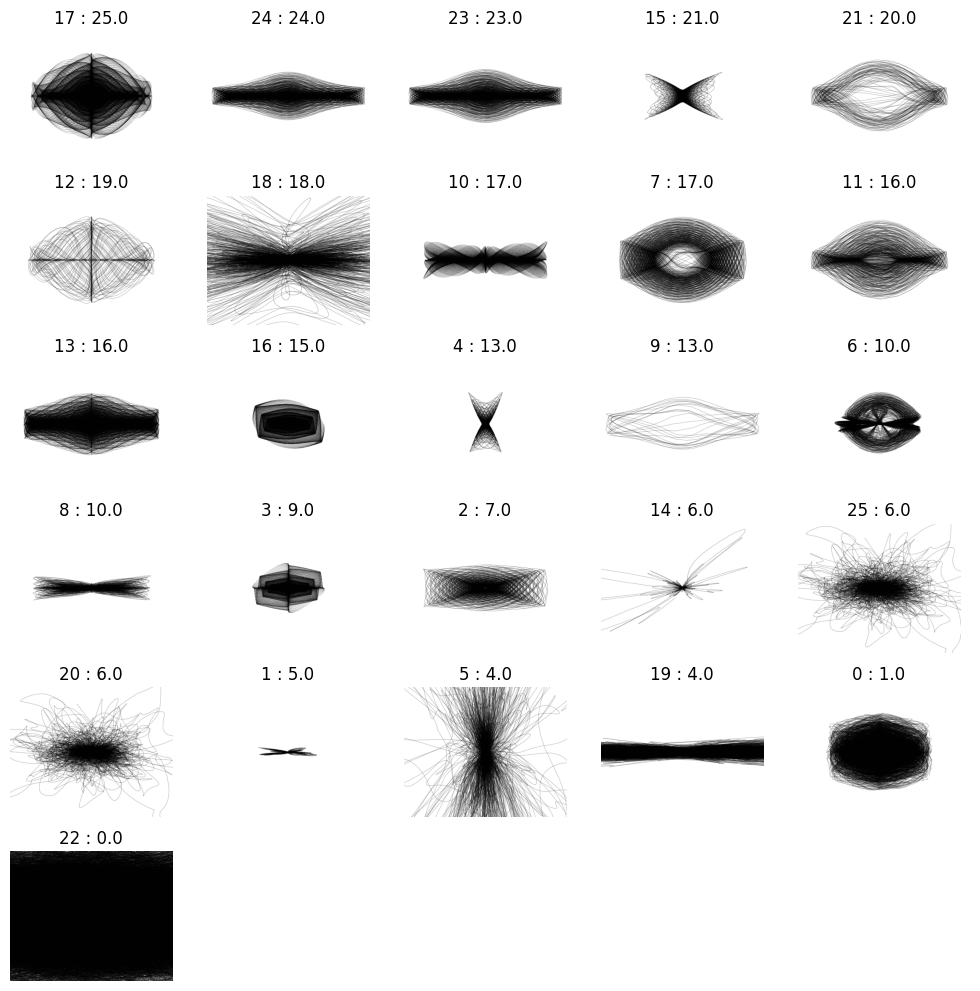

---------------------
Image run1_0.png	 Rank Score: 1.0
Image run1_1.png	 Rank Score: 5.0
Image run1_2.png	 Rank Score: 7.0
Image run1_3.png	 Rank Score: 9.0
Image run1_4.png	 Rank Score: 13.0
Image run1_5.png	 Rank Score: 4.0
Image run1_6.png	 Rank Score: 10.0
Image run1_7.png	 Rank Score: 17.0
Image run1_8.png	 Rank Score: 10.0
Image run1_9.png	 Rank Score: 13.0
Image run1_10.png	 Rank Score: 17.0
Image run1_11.png	 Rank Score: 16.0
Image run1_12.png	 Rank Score: 19.0
Image run1_13.png	 Rank Score: 16.0
Image run1_14.png	 Rank Score: 6.0
Image run1_15.png	 Rank Score: 21.0
Image run1_16.png	 Rank Score: 15.0
Image run1_17.png	 Rank Score: 25.0
Image run1_18.png	 Rank Score: 18.0
Image run1_19.png	 Rank Score: 4.0
Image run1_20.png	 Rank Score: 6.0
Image run1_21.png	 Rank Score: 20.0
Image run1_22.png	 Rank Score: 0.0
Image run1_23.png	 Rank Score: 23.0
Image run1_24.png	 Rank Score: 24.0
Image run1_25.png	 Rank Score: 6.0
---------------------


In [27]:
rank(prompt)

## Attempt reasoning (single job)

In [6]:
prompt = """You will be given two images depicting harmonograph drawings, you must choose which one is more aesthetically pleasing in representing harmonic patterns.

IMPORTANT RULES (must be followed):
- Images that are mostly dark blobs or solid dark regions MUST be ranked lower.
- Visible line structure and repeating patterns are REQUIRED for a high score.
- Messy noise or amorphous shapes should be ranked lower.
- Winning designs must posses the best INTRICATE and CLEAR harmonic patterns.

Task:
Choose which image is more aesthetically pleasing according to the rules above.
Output a one sentence description of each image, a single sentence regarding your reasining and finally a single digit corresponding to which image is better ONLY '1' or '2'."""

In [7]:
# read images to compare
img1 = "run1_18.png"
img2 = "run1_10.png"
filepath = "/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images"

images = [img1, img2]
jobs = build_messages(images, filepath, prompt)
results = processor.process_batch_parallel(jobs)
results[0]["result"]


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


'Image 1: A chaotic burst of intersecting lines radiating from a central dark core, creating a visually dense but disorganized pattern.  \nImage 2: A symmetrical, layered wave-like structure with clear, repeating harmonic curves forming elegant, flowing forms.  \nImage 2 is superior because its intricate, repeating harmonic patterns are clear, balanced, and aesthetically harmonious, while Image 1’s chaotic lines lack structure and visual coherence.  \n2'

In [8]:
def build_single_message(job_id: str,image1: str, image2: str, filepath: str, prompt: str) -> ComparisonJob:
    """
    Function builds a single comparison job
    """

    return ComparisonJob(job_id=job_id,
                        image1_path=os.path.join(filepath, image1),
                        image2_path=os.path.join(filepath, image2),
                        system_prompt=prompt)

In [55]:
# sample n image pairs and generate comparisons
n = 5
sampled_indices = np.random.choice(len(image_filepaths), size=(n, 2), replace=False)
sampled_images = [(image_filepaths[i1], image_filepaths[i2]) for i1, i2 in sampled_indices]

jobs = []
for i, (img1, img2) in enumerate(sampled_images):
    job = build_single_message(job_id=f"job_{img1.split('_')[-1].strip('.png')}_{img2.split('_')[-1].strip('.png')}", image1=img1, image2=img2, filepath=image_dir, prompt=prompt)
    jobs.append(job)


In [56]:
# predict results
results = processor.process_batch_parallel(jobs)

In [57]:
results

[{'job_id': 'job_22_5',
  'status': 'success',
  'result': '2',
  'image1': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_22.png',
  'image2': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_5.png'},
 {'job_id': 'job_23_18',
  'status': 'success',
  'result': '1',
  'image1': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_23.png',
  'image2': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_18.png'},
 {'job_id': 'job_10_6',
  'status': 'success',
  'result': '1',
  'image1': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_10.png',
  'image2': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_6.png'},
 {'job_id': 'job_19_13',
  'status': 'success',
  'result': '2',
  'image1': '/home/sj

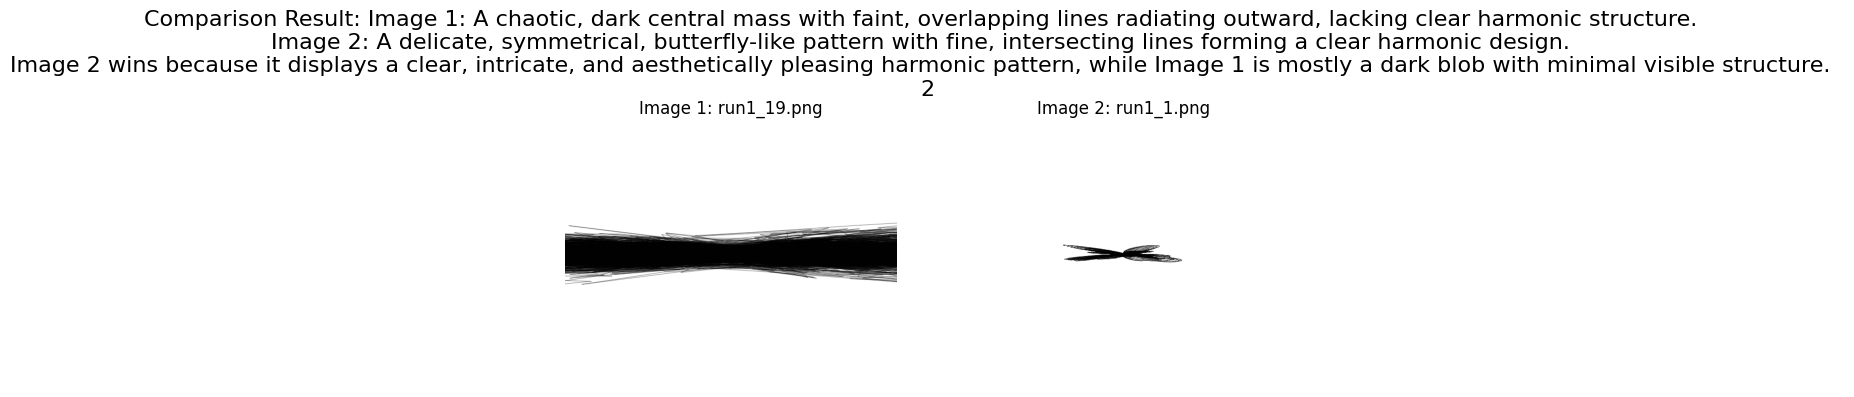

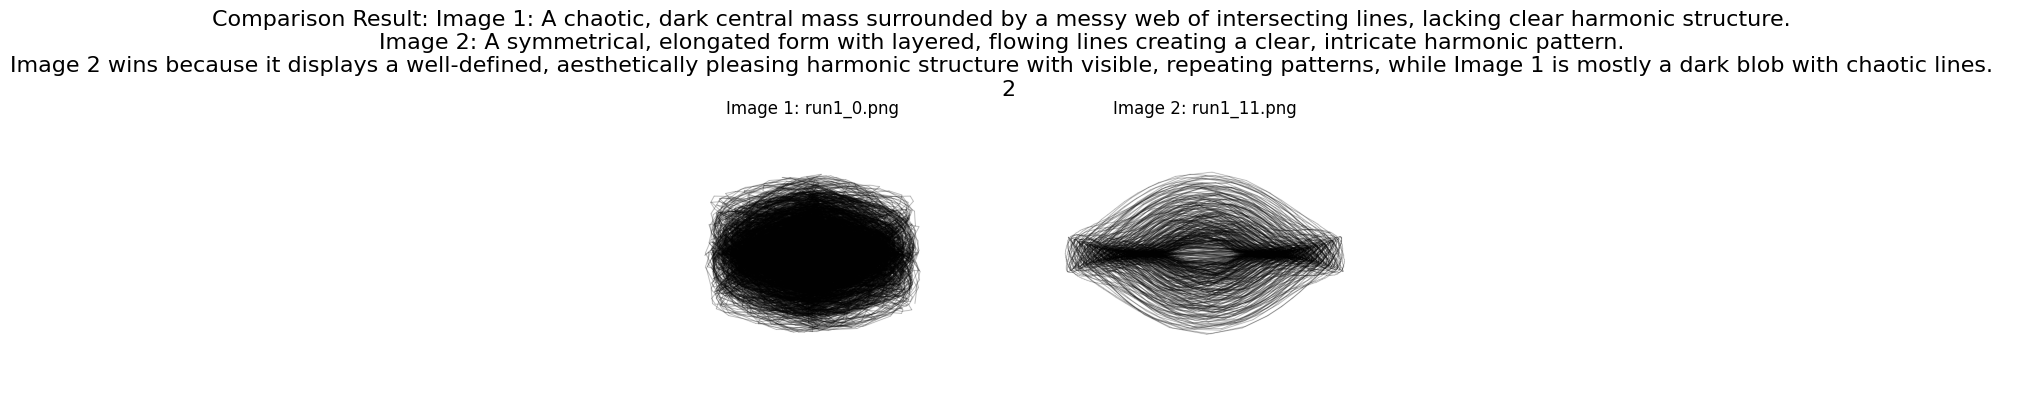

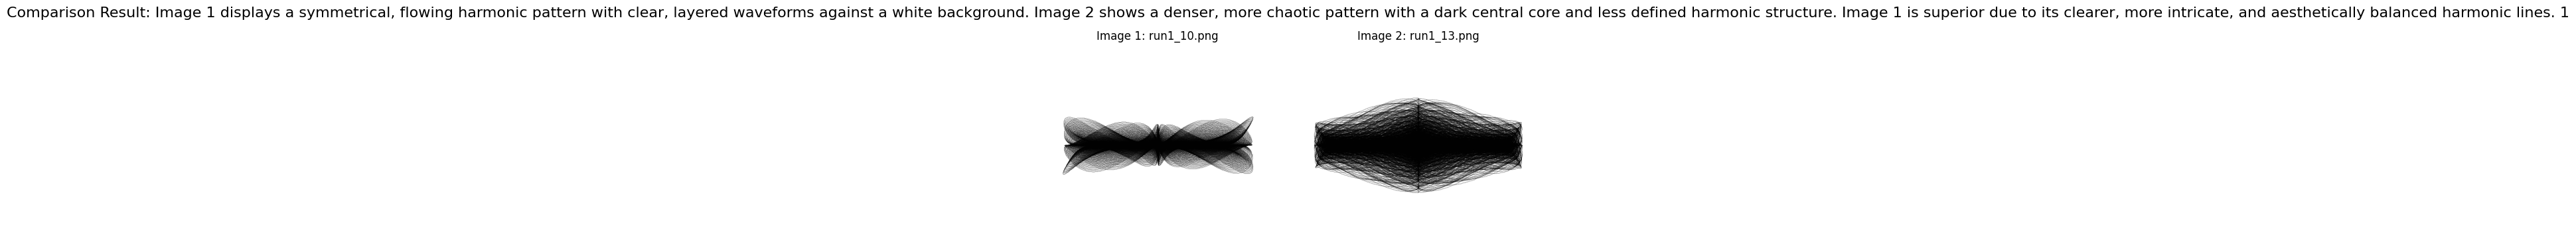

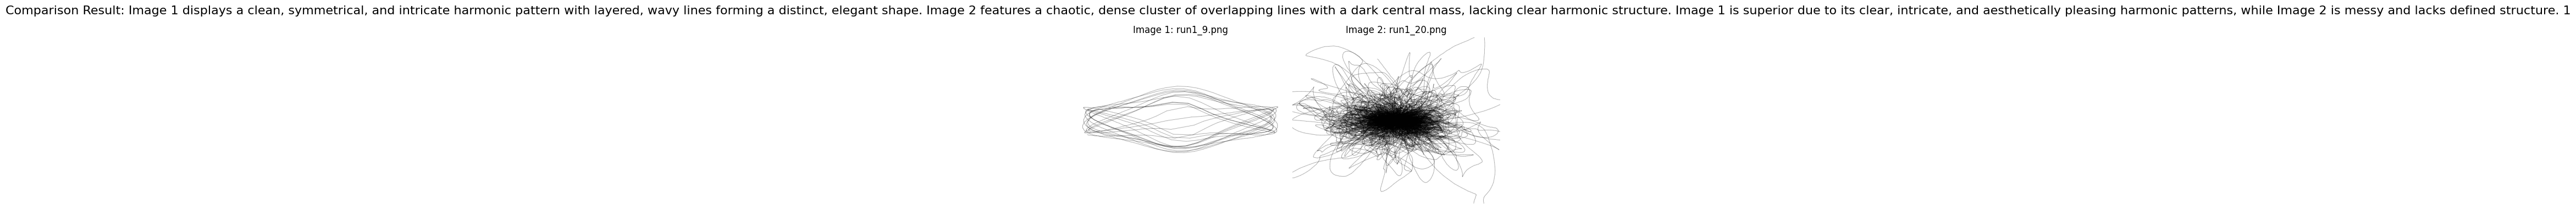

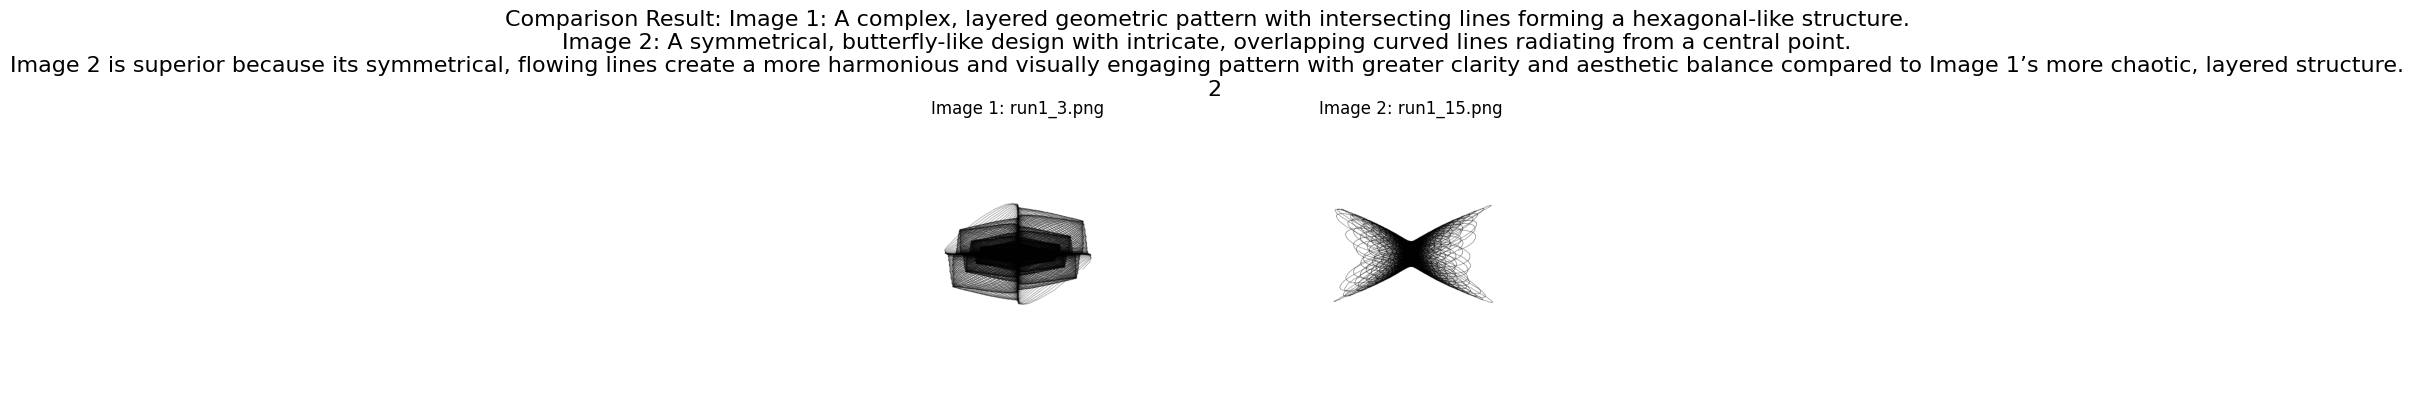

In [53]:
# plot image pairs and their results
for res in results:
    img1_path = res["image1"]
    img2_path = res["image2"]
    result = res["result"]

    img1 = plt.imread(img1_path)
    img2 = plt.imread(img2_path)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1)
    axes[0].set_title(f"Image 1: {os.path.basename(img1_path)}")
    axes[0].axis('off')

    axes[1].imshow(img2)
    axes[1].set_title(f"Image 2: {os.path.basename(img2_path)}")
    axes[1].axis('off')

    plt.suptitle(f"Comparison Result: {result}", fontsize=16)
    plt.tight_layout()
    plt.show()

Processing 325 jobs in chunks of 32...


100%|██████████| 11/11 [01:07<00:00,  6.09s/it]


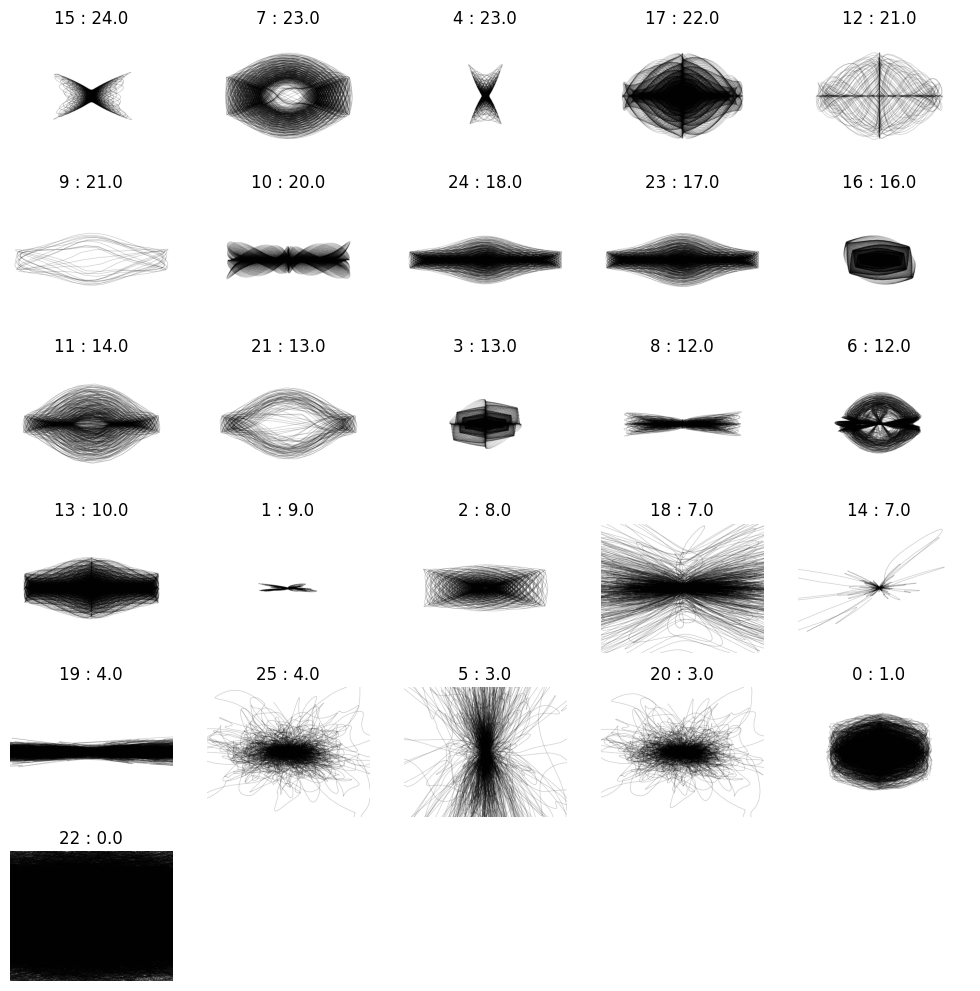

---------------------
Image run1_0.png	 Rank Score: 1.0
Image run1_1.png	 Rank Score: 9.0
Image run1_2.png	 Rank Score: 8.0
Image run1_3.png	 Rank Score: 13.0
Image run1_4.png	 Rank Score: 23.0
Image run1_5.png	 Rank Score: 3.0
Image run1_6.png	 Rank Score: 12.0
Image run1_7.png	 Rank Score: 23.0
Image run1_8.png	 Rank Score: 12.0
Image run1_9.png	 Rank Score: 21.0
Image run1_10.png	 Rank Score: 20.0
Image run1_11.png	 Rank Score: 14.0
Image run1_12.png	 Rank Score: 21.0
Image run1_13.png	 Rank Score: 10.0
Image run1_14.png	 Rank Score: 7.0
Image run1_15.png	 Rank Score: 24.0
Image run1_16.png	 Rank Score: 16.0
Image run1_17.png	 Rank Score: 22.0
Image run1_18.png	 Rank Score: 7.0
Image run1_19.png	 Rank Score: 4.0
Image run1_20.png	 Rank Score: 3.0
Image run1_21.png	 Rank Score: 13.0
Image run1_22.png	 Rank Score: 0.0
Image run1_23.png	 Rank Score: 17.0
Image run1_24.png	 Rank Score: 18.0
Image run1_25.png	 Rank Score: 4.0
---------------------


In [7]:
results = rank(prompt)

In [62]:
results

[{'job_id': 'comparison_0_1',
  'status': 'success',
  'result': 'Image 1: A dense, chaotic scribble of intersecting lines forming a dark, amorphous oval with no discernible harmonic pattern.  \nImage 2: A delicate, symmetrical figure resembling a butterfly or dragonfly with clear, repeating linear patterns and defined structure.  \nImage 2 is superior because it displays intricate, clear harmonic patterns with visible structure, while Image 1 is a messy, amorphous blob lacking defined harmonic design.  \n2',
  'image1': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_0.png',
  'image2': '/home/sjkro1/ARC-Discovery/aesthetic-evolution/Experiments/file-structure-change/run1/Images/run1_1.png'},
 {'job_id': 'comparison_0_2',
  'status': 'success',
  'result': 'Image 1: A dense, chaotic scribble of intersecting lines forms a dark, amorphous oval with no discernible harmonic pattern.  \nImage 2: A complex, elongated harmonograph pattern wi

'2'